In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from encoder_decoder import*
import matplotlib.pyplot as plt

# Check vocab and define encoding/decoding functions (from int to char and viceversa)

In [2]:
# first import the little dictionary frol it_es_cognates.txt

italian_words = []
spanish_words = []

with open("it_es_cognates.txt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        it, es = line.split(";") # words separated by ;
        italian_words.append(it.lower())
        spanish_words.append(es.lower())

# check the number of words in the list of cognates
print(len(italian_words), "pairs")
print(italian_words[:5], spanish_words[:5])

# find all characters appearing in the list of cognates
all_chars = set()
for word in spanish_words + italian_words:
    all_chars.update(word)
all_chars = sorted(all_chars)

# add the special caracters: pad, start of string, end of string, unknown
specials = ['<pad>', '<sos>', '<eos>', '<unk>']
vocab = specials + all_chars

# build the dictionaries, just use the enumeration of vocab to assign an integer to every character
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

# check the characters in the vocabulary, and its length
print("vocab: ", vocab)
print("vocab length:", len(vocab))

# test word size in the vocabulary (need to know the dimension of the words I am going to have in the model - by padding)
# I will add 2 or 3 just to be on the safe side for future additions to the dictionary, getting, say, to 20
print("Max length of spanish words: ", max(len(w) for w in spanish_words))
print("Max length of italian words: ", max(len(w) for w in italian_words))

def encode_source(word, max_len = 20):
    # input: no sos/eos needed
    ids = [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len] # use the char to int dictionary
    ids += [char_to_idx['<pad>']] * (max_len - len(ids)) # fill with '<pad>' until the prescribed length max_len
    return torch.tensor(ids)

def encode_target(word, max_len = 20):
    # output: needs sos/eos since decoder generates it step by step, they will replace two <pad> 
    ids = [char_to_idx['<sos>']] + [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len-2] + [char_to_idx['<eos>']]
    ids += [char_to_idx['<pad>']] * (max_len - len(ids))
    return torch.tensor(ids) 

def decode_source(ids):
    
    ids_numpy = ids.numpy()
    chars = []
    for i in ids_numpy:
        ch = idx_to_char[i] # use the integer to char dictionary
        if ch == '<pad>':
            break  # padding marks the end of real content
        chars.append(ch)
    return ''.join(chars)

# test
print(encode_source('castoro'))
print(decode_source(encode_source('castoro'))) 
print(decode_source(encode_source('è'))) # check unknown characters


# now test the embedding
vocab_size = len(char_to_idx)
d_model = 32 # needs to be large enough but does not have to be larger than number of characters - in fact for LLMs it is smaller than the number of tokens
embed = nn.Embedding(vocab_size, d_model, padding_idx=char_to_idx['<pad>'])

print(embed(encode_source('castoro')))

909 pairs
['acqua', 'aglio', 'aiutare', 'aiutata', 'aiutate'] ['agua', 'ajo', 'ayudar', 'ayudada', 'ayudadas']
vocab:  ['<pad>', '<sos>', '<eos>', '<unk>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', 'à', 'á', 'é', 'í', 'ñ', 'ó', 'ù', 'ú']
vocab length: 36
Max length of spanish words:  15
Max length of italian words:  13
tensor([ 6,  4, 21, 22, 17, 20, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0])
castoro
<unk>
tensor([[ 2.1534e-01,  1.0945e-01, -2.8732e+00,  1.5896e+00,  9.1098e-01,
         -2.4540e+00, -5.3656e-01,  9.1579e-02,  3.1573e-01,  4.8372e-01,
          8.1652e-01, -6.6273e-01,  2.0701e-01, -9.5410e-01,  3.9237e-01,
         -8.1808e-01, -5.5234e-03,  1.3337e+00,  1.0067e+00,  2.4597e+00,
          7.8398e-01, -8.7581e-01, -1.0334e+00,  2.9217e-01,  4.9428e-01,
         -2.0464e+00,  1.8694e-01,  1.4148e+00, -9.3219e-01, -7.2444e-01,
          3.7462e-01, -7.2442e-01],
        [ 

# Various tests done while coding the class

In [3]:
# test if Encoder runs correctly

enco = Encoder(2, d_model = d_model, d_hidden = 4*d_model, dk = 8, dv = 8, h = 4)
pos_enco = PositionalEncodingModule(d_model=d_model)

encoded_word = pos_enco(enco(embed(encode_source('castoro')).unsqueeze(0)))
# print(encoded_word)

# ok

# test if Transformer runs correctly 

trafo = Transformer(n_layers = 3, d_model = d_model, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8)

print(trafo(encode_source("castoro").unsqueeze(0), encode_source("diga").unsqueeze(0)))
print(trafo.generate_sequence(encode_source("castoro").unsqueeze(0)))

tensor([[[-2.9851e-01, -4.2609e-01, -6.9452e-01,  7.4540e-01,  6.5600e-01,
          -5.5754e-01, -6.4895e-01,  1.9296e-02, -1.6473e-01, -2.9030e-01,
          -4.1462e-01,  5.4491e-01,  1.3080e-01, -4.0893e-01, -7.3739e-01,
           9.9328e-01,  4.1997e-01,  7.6331e-02, -3.4188e-02,  5.3007e-01,
          -6.5623e-01,  1.0754e+00, -1.1775e+00,  1.2191e-02, -3.7512e-01,
          -5.3817e-02,  4.8052e-02, -9.9113e-02,  2.4274e-01,  4.4841e-02,
          -3.9184e-01, -3.8249e-01, -4.8194e-01, -5.3549e-01, -3.2938e-01,
           3.9651e-01],
         [-9.0366e-01,  2.9900e-01, -1.3535e+00, -2.1966e-01, -3.9663e-02,
           2.1433e-01,  5.9336e-02,  9.0180e-01, -3.9719e-01, -1.6894e-01,
          -7.2545e-01,  1.0466e-02,  3.5039e-01,  5.8286e-04,  1.2750e-01,
           8.6298e-01,  2.2159e-01, -4.2393e-01, -2.3219e-01,  2.1199e-01,
           4.2237e-01, -1.8153e-01, -7.4103e-01, -2.5886e-01, -2.7895e-01,
          -4.9666e-01, -9.5553e-01, -1.7795e-01,  6.2832e-01, -5.8382e-02,
 

In [4]:
def count_parameters_by_module(model: nn.Module, trainable_only: bool = True) -> dict:
    """counts the number of parameters, in total and for every submodule"""
    counts = {}
    for name, module in model.named_children():
        if trainable_only:
            n = sum(p.numel() for p in module.parameters() if p.requires_grad)
        else:
            n = sum(p.numel() for p in module.parameters())
        counts[name] = n
    counts["TOTAL"] = sum(counts.values())
    return counts

count_parameters_by_module(trafo)

{'embed': 1152,
 'pos_encoding': 0,
 'encoder': 38112,
 'decoder': 50976,
 'exit_linear_projection': 1188,
 'criterion': 0,
 'TOTAL': 91428}

# Fit the model

In [12]:
trafo = Transformer(n_layers = 2, d_model = d_model, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, lr = 0.01)
# lr = 0.01 seems to work as starting learning rate
trafo.fit_from_txt("it_es_cognates.txt", n_epochs=750)

Epoch  0 / 750  loss =  3.8380870819091797  loss_eval =  3.856750726699829
Epoch  100 / 750  loss =  0.09687398374080658  loss_eval =  1.432495355606079
Epoch  200 / 750  loss =  0.005919814575463533  loss_eval =  1.8159388303756714
Epoch  300 / 750  loss =  0.0037175407633185387  loss_eval =  1.9104571342468262
Epoch  400 / 750  loss =  0.003094783518463373  loss_eval =  1.9519166946411133
Epoch  500 / 750  loss =  0.0028364018071442842  loss_eval =  1.9733778238296509
Epoch  600 / 750  loss =  0.0027129536028951406  loss_eval =  1.9847538471221924
Epoch  700 / 750  loss =  0.002649932634085417  loss_eval =  1.9908512830734253


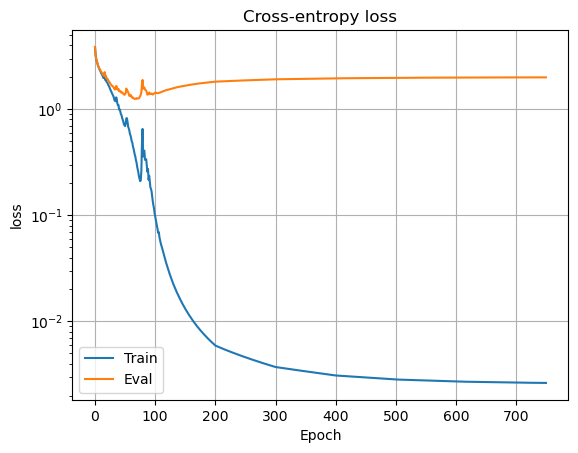

In [13]:
plt.figure()
plt.title('Cross-entropy loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid()
plt.semilogy(trafo.epochs, trafo.losses, label = 'Train')
plt.semilogy(trafo.epochs, trafo.losses_eval, label = 'Eval')
plt.legend()
plt.show()

def translate_string(word):
    encoded_input = encode_source(word).unsqueeze(0)
    generated_sequence = trafo.generate_sequence(encoded_input).cpu().squeeze()[1:-1] # exclude sos at beginning and eos at end

    return decode_source(generated_sequence)

In [20]:
italian_words = ["aiutato", "aiutate", "speciale", "speciali", "sperato", "letto", "letti", "gatto", "andato", "nave", "croci", "croce", "dito"]
expected_spanish_cognates = [translate_string(word) for word in italian_words]

for k in range(len(italian_words)):
    print(italian_words[k], "  ", expected_spanish_cognates[k])

aiutato    ayudado
aiutate    ayudadas
speciale    especial
speciali    especalia
sperato    perta
letto    lecho
letti    ledilos
gatto    gato
andato    ando
nave    nave
croci    crico
croce    coras
dito    dedo


In [ ]:
# basically, overfitting: works fine on training dataset but not very well on random words
# same phenomenon if I change the number of layers n_layers
# need bigger dataset